In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

from Model.WGAN import Generator , Discriminator

In [2]:
device = torch.device("mps")

In [3]:
Generator = Generator(100).to(device)
Discriminator = Discriminator().to(device)

In [4]:
Checkpoint = torch.load("./WGAN-Generated/Checkpoint_WGAN_GP.pt", map_location=torch.device('mps'))



In [5]:
Generator.load_state_dict(Checkpoint["Generator"])
Generator.eval()
print(f"Loaded checkpoint from epoch {Checkpoint['Epoch']}")

Loaded checkpoint from epoch 1999


## Single generated sample

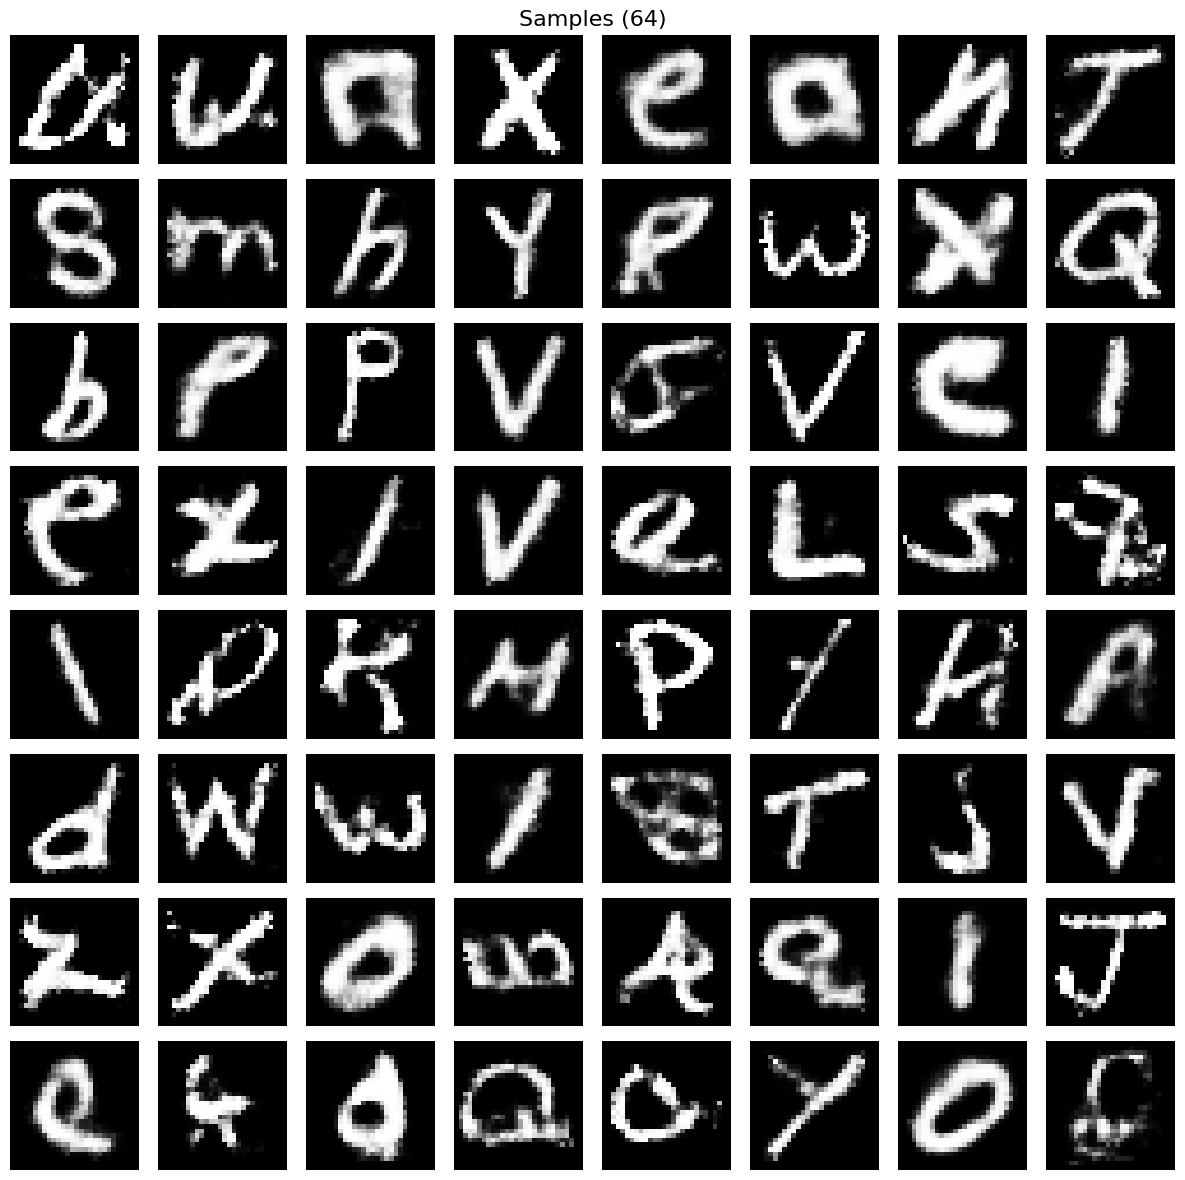

In [6]:
import numpy as np

Z = torch.randn((64, 100), device=device)

with torch.no_grad():
    fakes = Generator(Z)  # (64, 784)

# Reshape, rotate 90°, denormalize
imgs = fakes.reshape(64, 28, 28).cpu().numpy()
imgs = np.flip(imgs, axis=1)              # flip each image vertically (up-down)
imgs = np.rot90(imgs, k=1, axes=(1, 2))  # then rotate 90° CCW
imgs = (imgs + 1) / 2
imgs = np.flip(imgs, axis=(1, 2))        # flip both axes


n = 8
fig, axes = plt.subplots(n, n, figsize=(12, 12))
for idx, ax in enumerate(axes.flat):
    ax.imshow(imgs[idx], cmap='gray')
    ax.axis('off')

plt.suptitle('Samples (64)', fontsize=16)
plt.tight_layout()
plt.show()

## Training losses

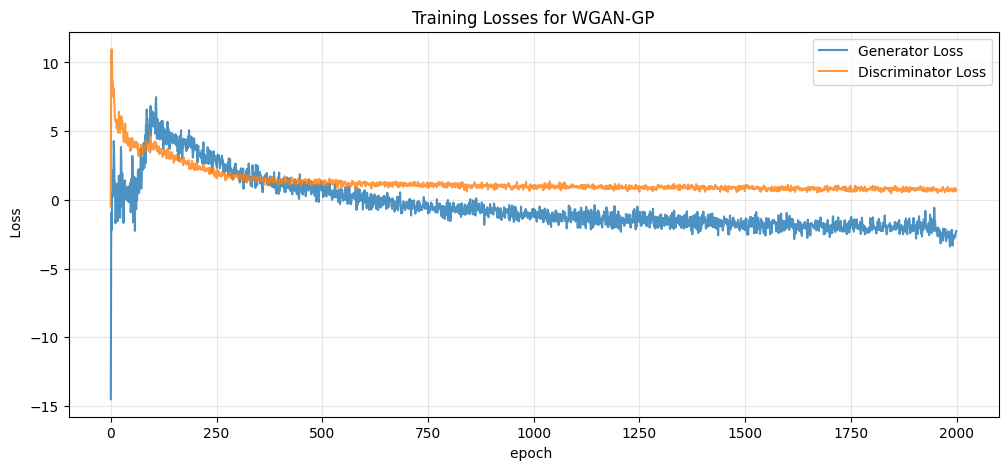

In [7]:
LossesG = np.array([i.to(torch.device("cpu")) for i in Checkpoint["LossesG"]])
LossesD = np.array([i.to(torch.device("cpu")) for i in Checkpoint["LossesD"]])

plt.figure(figsize=(12, 5))
plt.plot(LossesG, label='Generator Loss', alpha=0.8)
plt.plot(LossesD, label='Discriminator Loss', alpha=0.8)
plt.xlabel('epoch ')
plt.ylabel(' Loss')
plt.title('Training Losses for WGAN-GP')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()